# Tarea 3: Aprendizaje no supervisado
La tercera tarea consiste en aplicar técnicas de aprendizaje no supervisado para identificar perfiles de estudiantes y patrones en los datos. Para ello, vamos a separar el análisis en tres partes:
- PCA (reducción de dimensionalidad: visualizar los datos y detectar las direcciones de máxima varianza)
- K-Means: agrupamos estudiantes en clusters según su perfil.
- Selección de k: implementaré el método del codo y el de la silueta para compararlos y obtener el número óptimo de clusters.

## 1. Importaciones

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as PCA_sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sys.path.append(os.path.abspath(".."))
from src.preprocesado import plot_varianza_pca

## 2. Carga de datos    

In [68]:
df = pd.read_pickle("../data/df_limpio.pkl")
df.head()

,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna,cualificacion_previa,nota_cualificacion_previa,cualificacion_madre,cualificacion_padre,ocupacion_madre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,0,acceso_general,5,diseno_y_multimedia,1,secundaria,122.0,basica,secundaria,servicios,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,0,internacional,1,NaN,1,secundaria,160.0,secundaria,superior,media_cualificacion,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,0,acceso_general,5,diseno_y_multimedia,1,secundaria,122.0,basica,basica,manual_no_cualificado,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,0,acceso_general,2,diseno_y_multimedia,1,secundaria,122.0,basica,basica,servicios,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,1,edad,1,ciencias_sociales,0,secundaria,100.0,basica,basica,manual_no_cualificado,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


## 3. Selección de variables        
Para esta parte del proyecto, usamos un subconjunto razonado de variables que describan el perfil académico del estudiante. En este caso, al no haber un target que opredecir, no hay riesgo de data leakage, por lo que podemos incluir las variables relacionadas con el segundo semestre. Y además serán muy informativas, ya que un estudiante con estudiante con rendiemiento en ambos sesmestre tiene un perfil más completo que solo el primero. 

Excluiremos las variables macroeconómicas y de entorno porque son las que menos informan sobre el estudiante como individuo, y la varibale objetivo. También excluiré las categóricas multinomiales porque PCA y K-Means trabajan con distancias euclídeas y varianzas, que cuando se aplica a variables codificadas con One-hot encoding pierde un poco el sentido. Además, aplicar One-Hot a variables con muchas categorias genera muchas columnas binarias que "diluyen" la varianza de otras variables y lo hacen menos interpretable.

In [69]:
#demograficas, acceso previo, socioeconomicas, 1sem, 2sem
variables = ['nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse', 'es_mujer', 'desplazado', 'asistencia_diurna',
    'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'becado',
    'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas',
    'asignaturas_1sem_aprobadas', 'nota_media_1sem',
    'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas',
    'asignaturas_2sem_aprobadas', 'nota_media_2sem',
    'asignaturas_2sem_sin_evaluacion']

X = df[variables].copy()
print(X.describe())

       nota_cualificacion_previa  nota_admision  edad_al_matricularse  \
count                4424.000000    4424.000000           4424.000000   
mean                  132.613314     126.978119             23.265145   
std                    13.188332      14.482001              7.587816   
min                    95.000000      95.000000             17.000000   
25%                   125.000000     117.900000             19.000000   
50%                   133.100000     126.100000             20.000000   
75%                   140.000000     134.800000             25.000000   
max                   190.000000     190.000000             70.000000   

          es_mujer   desplazado  asistencia_diurna  \
count  4424.000000  4424.000000        4424.000000   
mean      0.648282     0.548373           0.890823   
std       0.477560     0.497711           0.311897   
min       0.000000     0.000000           0.000000   
25%       0.000000     0.000000           1.000000   
50%       1.000000

### Estandarización     
Tenemos que recordar que tanto PCA como K-Means son sensibles a la escala de las variables porque se basan en, así usamos StandardScaler para ello. Si no estandarizamos, las variables con mayor rango numérico dominarán el análisis aunque no necesariamente sean las mas importantes. 

In [70]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print("X estandarizada")
print(f"media: {X_std.mean():.4f}, std: {X_std.std():.4f}")

X estandarizada
media: -0.0000, std: 1.0000


## 4. PCA       
PCA busca las direcciones del espacio de variables en las que los datos tengan mayor varianza. Estas direccionas serán los autovectores de la matriz de covarianza X.T @ X, ordenados de mayor a menor autovalor. 

Cada componente principal es una combinación lineal de las variables originales con dos restricciones: los vectores de dirección tienen norma 1 y son ortogonales entre sí.

In [71]:
def pca(X, n_components):
    """
    Implementación a mano de PCA
    Args:
        X: tiene que estar estandarizado 
        n_components: número de componentes que elegimos
    
    Returns
        los datos proyectados y la varianza explicada por cada componente
    """
    n_samples, n_features = X.shape
    
    cov = (X.T@X)/(n_samples)  # matriz de covarianzas
    autovals, autovecs = np.linalg.eigh(cov)

    id = np.argsort(autovals)[::-1]  # ordenar de mayor a menos autovalor
    autovals = autovals[id]
    autovecs = autovecs[:, id]

    componentes = autovecs[:, :n_components]  # selccionar los n_componentes primeros
    Z = X @ componentes  # proyecta los datos

    varianza_explicada = autovals[:n_components]/autovals.sum()
    return Z, varianza_explicada, componentes


### Varianza explicada      
Antes de decidir cuantos componentes usar, vamos a analizar cuánta varianza acumula cada uno para quedarnos con el mínimo número de componentes que explique una proporción razonable de la varianza total, apreoximadamente mayor que el 80%.

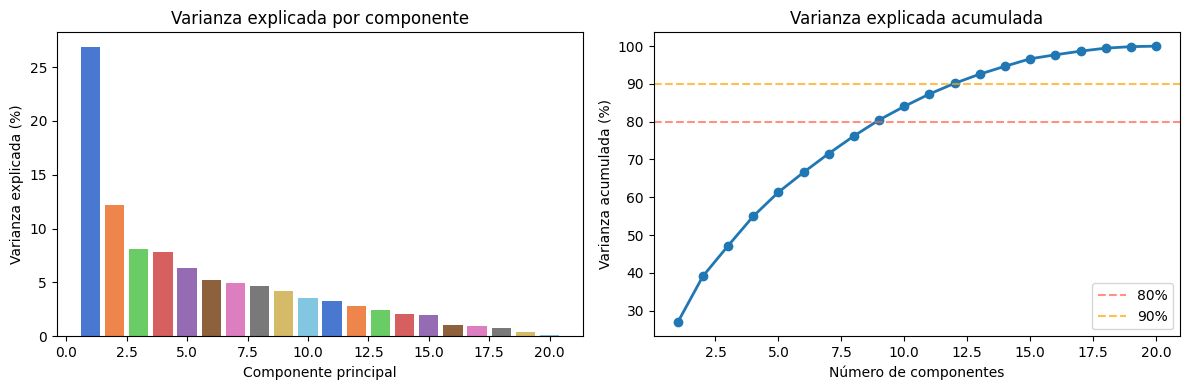

  PC1: 26.9%  (acumulada: 26.9%)
  PC2: 12.2%  (acumulada: 39.1%)
  PC3: 8.1%  (acumulada: 47.2%)
  PC4: 7.8%  (acumulada: 55.0%)
  PC5: 6.4%  (acumulada: 61.3%)
  PC6: 5.3%  (acumulada: 66.6%)
  PC7: 5.0%  (acumulada: 71.6%)
  PC8: 4.6%  (acumulada: 76.2%)
  PC9: 4.2%  (acumulada: 80.5%)
  PC10: 3.6%  (acumulada: 84.1%)
  PC11: 3.3%  (acumulada: 87.3%)
  PC12: 2.8%  (acumulada: 90.2%)
  PC13: 2.4%  (acumulada: 92.6%)
  PC14: 2.1%  (acumulada: 94.7%)
  PC15: 2.0%  (acumulada: 96.7%)
  PC16: 1.1%  (acumulada: 97.7%)
  PC17: 1.0%  (acumulada: 98.7%)
  PC18: 0.8%  (acumulada: 99.5%)
  PC19: 0.4%  (acumulada: 99.9%)
  PC20: 0.1%  (acumulada: 100.0%)


In [72]:
# VARIANZA EXPLICADA
z, var_total_explicada, comp = pca(X_std, n_components=X_std.shape[1])
plot_varianza_pca(var_total_explicada)

Los resultados muestran que la varianza está bastante repartida entre los componentes porque no hay ninguno que destaque por su nivel de varianza. De hecho, el primer componente explica solo el 26.9% de la varianza, lo que sugiere que no hay una única dimensión dominante. 

Siguiendo el criterio que habia dicho antes, si cogiesemos los componentes que acumulan como mínimo el 80% de la varianza, seleccionariamos los 9 primeros componentes. Esto significa que podemos representar el 80% de la información original con menos de  la mtad de las variables originales, que eran 20.

### Verificación con sklearn        
Comprobamos que nuestra implementación de PCA devuelve los mismos resultados que sklearn.decomposition.PCA

In [73]:
pca_sk = PCA_sklearn(n_components=2)
X_pca_sk = pca_sk.fit_transform(X_std)

_, var_exp2, _ = pca(X_std, n_components=2)

print('Varianza explicada con implementación propia: ',
      [round(v, 4) for v in var_exp2])
print('Varianza explicada con sklearn:               ',
      [round(v, 4) for v in pca_sk.explained_variance_ratio_])

diferencia = np.abs(var_exp2 - pca_sk.explained_variance_ratio_).max()
print(f'\nDiferencia máxima entre implementaciones: {diferencia:.6f}')

Varianza explicada con implementación propia:  [np.float64(0.2688), np.float64(0.1222)]
Varianza explicada con sklearn:                [np.float64(0.2688), np.float64(0.1222)]

Diferencia máxima entre implementaciones: 0.000000


## 5. K-MEANS       
K-Means agrupa los datos en k clusters, minimizando la suma de distancias al cuadrado de cada punto a su centroide. El algoritmo sigue los siguientes pasos:
- Elige un número k de clusters.
- Inicializa k centroides aleatoriamente.
- Asigna cada punto a su centroide más cercano.
- Recalcula centroides al centro del cluster.
- Repite la asignación de centroides y la actualización hasta minimizar ela suma de distancias al cuadrado.

In [74]:
def distancia_euclidea(X, centroides):
    """
    Devuelve matriz de dimensión n_samples x k con la distancia euclídea al cuadrado de cada punto a cada centroide.
    """
    distancias = np.sum((X[:, np.newaxis, :] - centroides[np.newaxis, :, :]) ** 2,axis=2)
    return distancias

def elegir_centroides(X, k, rng):
    """
    Elige k centroides inciales aleatorios.
    """
    indices = rng.choice(X.shape[0], size=k, replace=False)
    return X[indices].copy()

def asignar_cluster(X, centroides):
    """ 
    Asigna cada punto al centroide más cercano
    """
    distancias = distancia_euclidea(X, centroides)
    labels = np.argmin(distancias, axis=1)
    return labels

def reasignar_centroides(X, labels, k):
    """ 
    Recalcula cada centroide como la media de los puntos asignados.
    """
    centroides = np.zeros((k, X.shape[1]))
    for j in range(k):
        puntos_cluster = X[labels == j]
        if len(puntos_cluster) > 0:
            centroides[j] = puntos_cluster.mean(axis=0)
    return centroides


def k_means(X, k, max_iter=300, random_state=42):
    """
    Implementación propia de K-Means.
    Devuelve un dict con labels, centroides finales y WCSS.
    """
    rng = np.random.default_rng(random_state)
    centroides = elegir_centroides(X, k, rng)

    for _ in range(max_iter):
        labels = asignar_cluster(X, centroides)
        nuevos_centroides = reasignar_centroides(X, labels, k)

        # Convergencia: los centroides no cambian
        if np.allclose(centroides, nuevos_centroides):
            break
        centroides = nuevos_centroides

    # WCSS: suma de distancias al cuadrado al centroide asignado
    wcss = sum(
        np.sum((X[labels == j] - centroides[j]) ** 2)
        for j in range(k)
    )

    return {'labels': labels, 'centroides': centroides, 'wcss': wcss}

## 6. Selección de k        
### 6.1 ELBOW METHOD        
El método del codo ejecuta K-Means para distintos valores de k y representa la 'Within-Cluster Sum of Squares (WCSS)' en función de k. Al aumentar el número de clusters, el error siempre disminuye, pero hay a partir de un valor donde la mejora no compensa lo suficiente. Eso es lo que en la gráfica se asemeja a un codo y será el valor que escojamos.

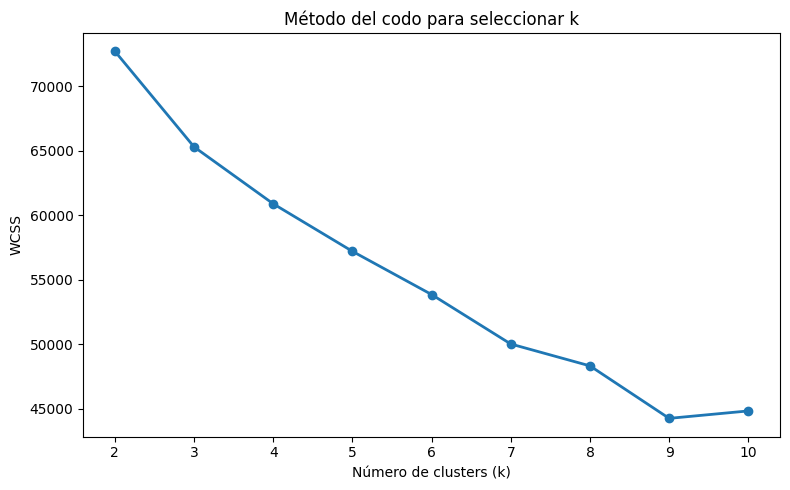

In [75]:
def elbow_method(X, valores_k, n_repeticiones=10, random_state=42):
    """ 
    Para cada k en valores_k, ejecuta K-Means n_repeticiones veces y devuelve la mínima WCSS de cada k.
    """
    rng = np.random.default_rng(random_state)
    valores_k = list(valores_k)
    wcss_values = []

    for k in valores_k:
        mejor_wcss = np.inf
        for _ in range(n_repeticiones):
            seed = int(rng.integers(0, 10**9))
            resultado = k_means(X, k=k, random_state=seed)
            if resultado['wcss'] < mejor_wcss:
                mejor_wcss = resultado['wcss']
        wcss_values.append(mejor_wcss)

    return {'k_values': valores_k, 'wcss_values': wcss_values}


# Ejecutamos el método del codo para k de 2 a 10
valores_k = range(2, 11)
resultados_elbow = elbow_method(X_std, valores_k)

plt.figure(figsize=(8, 5))
plt.plot(resultados_elbow['k_values'], resultados_elbow['wcss_values'],marker='o', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.title('Método del codo para seleccionar k')
plt.xticks(resultados_elbow['k_values'])
plt.tight_layout()
plt.show()

### 6.2 SILHOUETTE METHOD   
Este método selecciona el número de clusters que maximiza la separación media entre grupos y la cohesión interna de cada cluster. Esto lo calcula como la resta entre la distancia media al cluster vecino más cercano (b) menos la distancia media a los puntos de su cluster (a), dividido entre el máximo entre a y b. El valor está entre -1 y 1, siendo 1 el valor de que está bien asignado y b > a, y -1 que está mal asignado porque b < a. 

  k=2: silueta=0.2974
  k=3: silueta=0.2965
  k=4: silueta=0.2352
  k=5: silueta=0.1451
  k=6: silueta=0.1463
  k=7: silueta=0.1571
  k=8: silueta=0.1420
  k=9: silueta=0.1477
  k=10: silueta=0.1664

k óptimo seleccionado: 2


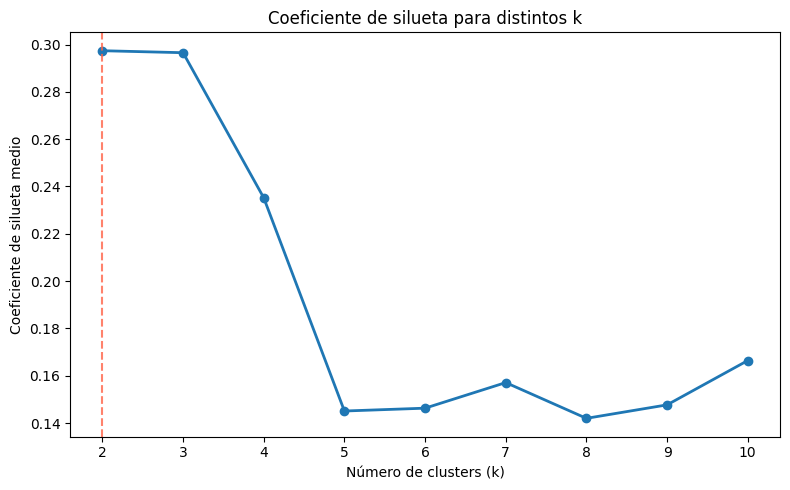

In [76]:
def coeficiente_silueta(X, labels):
    """
    Implementación propia del coeficiente de silueta medio.
    """
    n = X.shape[0]
    clusters = np.unique(labels)
    s = np.zeros(n)

    for i in range(n):
        cluster_i = labels[i]
        puntos_mismo = X[labels == cluster_i]

        if len(puntos_mismo) > 1:   # calculamos a
            a_i = np.mean(np.linalg.norm(puntos_mismo - X[i], axis=1))
        else:
            a_i = 0

        b_i = np.inf
        for c in clusters:         # calculamos b
            if c == cluster_i:
                continue
            puntos_c = X[labels == c]
            dist_c = np.mean(np.linalg.norm(puntos_c - X[i], axis=1))
            if dist_c < b_i:
                b_i = dist_c

        s[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
    return s.mean()


# calculamos la silueta para los mismos valores de k que antes
siluetas = []

for k in valores_k:
    resultado = k_means(X_std, k=k, random_state=42)
    sil = coeficiente_silueta(X_std, resultado['labels'])
    siluetas.append(sil)
    print(f'  k={k}: silueta={sil:.4f}')

# k óptimo: el que maximiza la silueta
k_optimo = list(valores_k)[siluetas.index(max(siluetas))]
print(f'\nk óptimo seleccionado: {k_optimo}')

plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), siluetas, marker='o', linewidth=2)
plt.axvline(k_optimo, color='tomato', linestyle='--', alpha=0.8, label=f'k elegido = {k_optimo}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de silueta medio')
plt.title('Coeficiente de silueta para distintos k')
plt.xticks(list(valores_k))
plt.tight_layout()
plt.show()

### Verificación con sklearn

In [77]:
print('Comparación implementación propia vs sklearn (coeficiente de silueta):\n')

for k in range(2, 6):
    # Implementación a mano
    res_propio = k_means(X_std, k=k, random_state=42)
    sil_propio = coeficiente_silueta(X_std, res_propio['labels'])

    # sklearn
    km_sk = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_sk = km_sk.fit_predict(X_std)
    sil_sk = silhouette_score(X_std, labels_sk)

    print(f'  k={k}: silueta propia={sil_propio:.4f} | silueta sklearn={sil_sk:.4f}')

Comparación implementación propia vs sklearn (coeficiente de silueta):

  k=2: silueta propia=0.2974 | silueta sklearn=0.2971
  k=3: silueta propia=0.2965 | silueta sklearn=0.2960
  k=4: silueta propia=0.2352 | silueta sklearn=0.1864
  k=5: silueta propia=0.1451 | silueta sklearn=0.1355


## 7. Clustering final y visualización.     
Con el valor óptimo de k encontrado con el codo y la silueta, ejecutamos K-Means final y visualizamos los clusters proyectados en el espacio PCA.

In [78]:
mejor_k = siluetas.index(max(siluetas)) + 2 # porque empezamos en k=2
print("K sugerido por la silueta: ", mejor_k)

resultado_final = k_means(X_std, k=mejor_k, random_state=42)
labels_final = resultado_final['labels']

K sugerido por la silueta:  2


Para visualizar los clusters, no solo vamos a mostrar los clusters obtenidos por K-Means usando las variables seleccionadas, sino que también vamos a graficar las clases reales según 'objetivo'. 

Cabe mencionar que en ningún momento hemos usado 'objetivo' para la parte no supervisada, pero lo mostramos simplemente como referencia para ver si los grupos descubiertos por K-Means se corresponden más o menos con las clases reales. Sirve para ver si el algoritmo ha detectado alguna estructura relevante en los datos sin haber usado las etiquetas. Pero si no coinciden, significa que K-Means ha encontrado otra agrupación basada en patrones distintos a los de la variable objetivo.

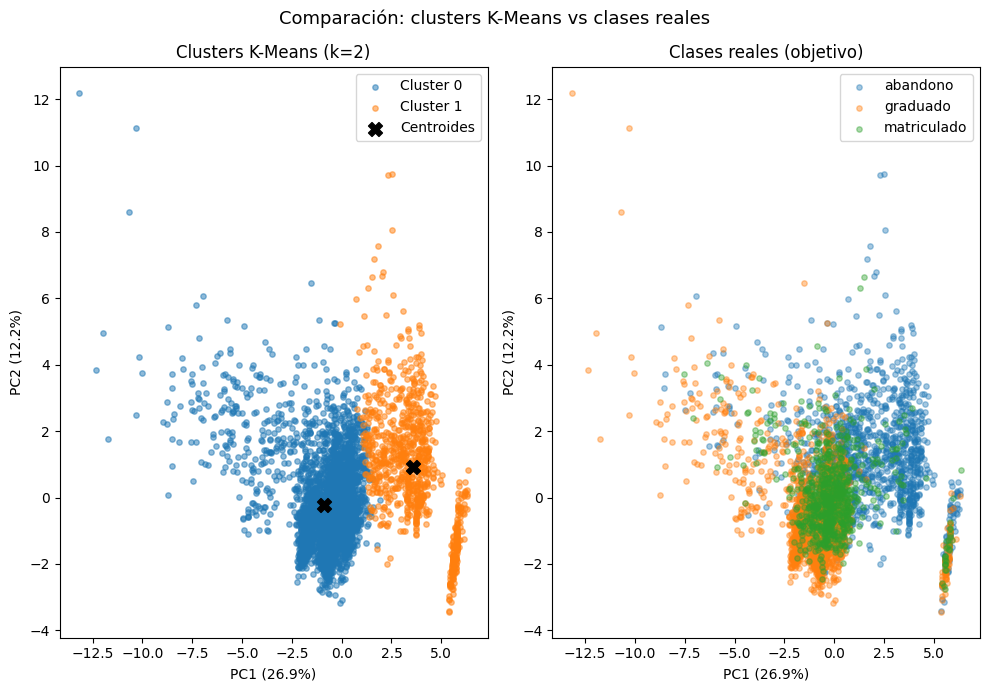

In [79]:
# Visualizamos en espacio PCA 2D
X_pca2, var_exp2, _ = pca(X_std, n_components=2)

fig, axes = plt.subplots(1, 2, figsize=(10,7))

# clusters k-means
for k in range(mejor_k):
    mask = labels_final == k
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=f'Cluster {k}', alpha=0.5, s=15)
centroides_pca = resultado_final['centroides'] @ pca(X_std, n_components=2)[2]
axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                c='black', marker='X', s=100, zorder=5, label='Centroides')
axes[0].set_xlabel(f'PC1 ({var_exp2[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp2[1]*100:.1f}%)')
axes[0].set_title(f'Clusters K-Means (k={mejor_k})')
axes[0].legend()

# Variable objetivo real
clases = df['objetivo'].unique()
colores_obj = dict(zip(clases, sns.color_palette('Set2', len(clases))))
for clase in clases:
    mask = df['objetivo'] == clase
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=clase, alpha=0.4, s=15)
axes[1].set_xlabel(f'PC1 ({var_exp2[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_exp2[1]*100:.1f}%)')
axes[1].set_title('Clases reales (objetivo)')
axes[1].legend()

plt.suptitle('Comparación: clusters K-Means vs clases reales', fontsize=13)
plt.tight_layout()
plt.show()


### Ahora bien... ¿Qué caracteriza a cada grupo?        
La división de los clusters no tiene sentido si no analizamos qué caracteriza a cada grupo, es decir, que tienen en común los estudiantes que k-means a agrupado juntos.

Para ello calculamos la media de cada variable por cluster. De esta forma, podemos comparar los perfiles de ambos grupos y darle un significado interpretable.

En nuestros resultados vemos claramente las diferencias entre los grupos:
- Cluster 0 es el perfil de estudiante con buen rendimiento académico. Aprueba la mayoría de asignaturas en ambos semestres (5.77 y 5.51 de media), obtiene medias de 12.7 puntos, tiene los pagos al día (0.93)y raramente es deudor (0.09).
- Cluster 1 parece el perfil de estudiante con bajo rendimiento. Aprueba pocas asignaturas (0.43 en el 1 semestre y 0.1 en el segundo), con notas medias bajas (2.24 y 0.69), con mayor propporción de deudores (0.2) y menor porcentaje de pagos al día (0.69).

Uniendo estos resultados con la variables objetivo, podriamos decir que los perfiles del cluster 0 probablemente sean los de los estudiantes que se graduan, y los del cluster 1 los que abandonan.


In [80]:
df_cluster = X.copy()
df_cluster['cluster'] = labels_final

perfil = df_cluster.groupby('cluster').mean().round(2)
display(perfil)

,nota_cualificacion_previa,nota_admision,edad_al_matricularse,es_mujer,desplazado,asistencia_diurna,necesidades_educativas_especiales,deudor,matricula_al_dia,becado,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion
cluster,,,,,,,,,,,,,,,,,,,,
0,132.65,127.08,22.58,0.70,0.57,0.90,0.01,0.09,0.93,0.29,6.73,9.18,5.77,12.73,0.11,6.67,9.10,5.51,12.61,0.12
1,132.47,126.57,26.00,0.45,0.47,0.86,0.01,0.20,0.69,0.10,4.41,4.75,0.43,2.24,0.24,4.47,3.91,0.10,0.69,0.29


## 8. Conclusiones      
PCA muestra que las primeras componentes capturan principalmente la varianza relacionada con el rendimiento del primer semestre, lo que solo vuelve a confirmarnos que estas variables son las más informativas del dataset.

K-Means agrupa los estudiantes en clusters, que podriamos decir que se parecen un poco a las clases de Abandono, Matriculado y Graduado, aunque no del todo, lo que también era esperable.

Por último, el análisis de los perfiles de cada cluster nos enseña las características de cada uno, viendo que los de un grupo tienen claramente un perfil académico mejor que el otro.
